
Load Python libraries

In [1]:
import pandas as pd

import sys
!{sys.executable} -m pip install scikit-learn pandas matplotlib pennylane amazon-braket-pennylane-plugin

Loads cleaned data in QML notebook

In [2]:
df = pd.read_csv("../data/cleaned_wildfire_data.csv")
df.head()

,avg_tmax_c,avg_tmin_c,tot_prcp_mm,month,temp_range,hot_dry,zip3_890,zip3_894,zip3_895,zip3_900,...,zip3_959,zip3_960,zip3_961,zip3_975,zip3_976,risk,Year,zip,risk_score,predicted_risk
0,NaN,NaN,NaN,7.0,NaN,NaN,False,False,False,False,...,False,False,False,False,False,0,2019,95470.0,NaN,NaN
1,NaN,NaN,NaN,12.0,NaN,NaN,False,False,False,False,...,False,False,False,False,False,0,2018,93060.0,NaN,NaN
2,NaN,NaN,NaN,12.0,NaN,NaN,False,False,False,False,...,False,False,False,False,False,0,2018,93066.0,NaN,NaN
3,21.748387,11.432258,35.5,1.0,10.316129,0.61091,False,False,False,True,...,False,False,False,False,False,0,2018,90001.0,NaN,NaN
4,21.748387,11.432258,35.5,1.0,10.316129,0.61091,False,False,False,True,...,False,False,False,False,False,0,2018,90002.0,NaN,NaN


Selects quantum features (only uses 4 due to hardware limitations)

In [3]:
id_cols = ['zip', 'Year']
q_features = ['avg_tmax_c', 'tot_prcp_mm', 'month', 'hot_dry']
target = 'risk'

train_df = df[df['Year'] < 2023].copy()
test_df = df[df['Year'] == 2023].copy()

Xq_train = train_df[q_features]
yq_train = train_df[target].values

Xq_test = test_df[q_features]
yq_test = test_df[target].values

Fills empty NaN values with median of each column (since some quantum algorithms can't handle NaNs)

In [4]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

Xq_train_imputed = imputer.fit_transform(Xq_train)
Xq_test_imputed = imputer.transform(Xq_test)

Preprocessing for angle encoding on bounded angle range [-pi, pi]

In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))

Xq_train_angles = scaler.fit_transform(Xq_train_imputed)
Xq_test_angles = scaler.transform(Xq_test_imputed)

Xq_train_angles[:3], Xq_test_angles[:3]

(array([[ 0.82031762, -3.11075073,  0.28559933, -2.93652035],
        [ 0.82031762, -3.11075073,  3.14159265, -2.93652035],
        [ 0.82031762, -3.11075073,  3.14159265, -2.93652035]]),
 array([[ 0.82031762, -3.11075073, -1.99919533, -2.93652035],
        [ 0.82031762, -3.11075073, -1.42799666, -2.93652035],
        [ 0.82031762, -3.11075073, -1.42799666, -2.93652035]]))

Shows how imbalanced the data is and then modifies for a 3:1 ratio (more managable for QML)

In [6]:
from sklearn.utils import resample

train_pos_idx = np.where(yq_train == 1)[0]
train_neg_idx = np.where(yq_train == 0)[0]

n_pos_sample = 20
n_neg_sample = 60

Transforms dataset into managable subset for training by randomly selecting positive and negative examples and building feature and label arrays

In [7]:
sampled_pos_idx = resample(train_pos_idx, replace=False, n_samples=n_pos_sample, random_state=42)
sampled_neg_idx = resample(train_neg_idx, replace=False, n_samples=n_neg_sample, random_state=42)

train_idx_small = np.concatenate([sampled_pos_idx, sampled_neg_idx])
np.random.shuffle(train_idx_small)

Xq_train_small = Xq_train_angles[train_idx_small]
Xq_train_small = np.asarray(Xq_train_small, dtype=np.float64)
yq_train_small = yq_train[train_idx_small]
yq_train_small = np.asarray(yq_train_small, dtype=np.float64)

print("Small train set shape:", Xq_train_small.shape)
print("Positive rate:", yq_train_small.mean())

Small train set shape: (80, 4)
Positive rate: 0.25


Imports qml features

In [8]:
import pennylane as qml
from pennylane import numpy as pnp

BACKEND = 'local'
N_SHOTS = None
QPU_ARN = None

Defines the circuit by turning it into an optimizable function with angle encoding and entanglement

In [9]:
n_qubits = 4
n_layers = 2

print(BACKEND)

if BACKEND == 'local':
    dev = qml.device('braket.local.qubit', wires=n_qubits, shots = N_SHOTS)

elif BACKEND == 'sv1':
    dev = qml.device('braket.aws.qubit', device_arn = 'arn:aws:braket:::device/quantum-simulator/amazon/sv1', wires=n_qubits, shots = N_SHOTS)

elif BACKEND == 'qpu':
    dev = qml.device('braket.aws.qubit', device_arn = QPU_ARN, wires=n_qubits, shots = 100)

else:
    raise ValueError("BACKEND must be 'local', 'sv1', or 'qpu'")

@qml.qnode(dev, interface='autograd')
def qnode(x, weights):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

local


In [10]:
def quantum_model(x, weights):
    raw = qnode(x, weights)
    prob = (raw + 1) / 2
    return prob

Computes weighted loss so that missing a real wildfire is more costly

In [11]:
eps = 1e-8

pos_weight = (len(yq_train_small) - yq_train_small.sum()) / yq_train_small.sum()
pos_weight = float(pos_weight)

Instantiates loss function

In [12]:
def weighted_bce_loss(weights, X, y, pos_weight=1.0):
    losses = []
    for xi, yi in zip(X, y):
        p = quantum_model(xi, weights)
        p = pnp.clip(p, eps, 1 - eps)
        
        if yi == 1:
            loss = (-pos_weight * pnp.log(p + eps))
        else:
            loss = (-pnp.log(1 - p + eps))
        losses.append(loss)
    return pnp.mean(pnp.array(losses))

Initializes weights

In [13]:
np.random.seed(42)

weights = pnp.array(0.01 * np.random.randn(n_layers, n_qubits, 3), requires_grad=True)

Chooses optimizer and epochs (train time)

In [14]:
opt = qml.AdamOptimizer(stepsize=0.02)

epochs = 2
loss_history = []

Training loop

In [15]:
import time

start = time.time()
p = quantum_model(Xq_train_small[0], weights)
end = time.time()

print("One forward pass time:", end - start)
print("Prob:", p)

One forward pass time: 0.0653998851776123
Prob: 0.8572133795210755


In [16]:
for epoch in range(epochs):
    weights = opt.step(lambda w: weighted_bce_loss(w, Xq_train_small, yq_train_small, pos_weight), weights)
    loss_val = weighted_bce_loss(weights, Xq_train_small, yq_train_small, pos_weight)
    loss_history.append(loss_val)
    if(epoch % 5 == 0):
        print(f"Epoch {epoch}, Loss: {loss_val:.4f}")

Epoch 0, Loss: 1.2727


Plots loss

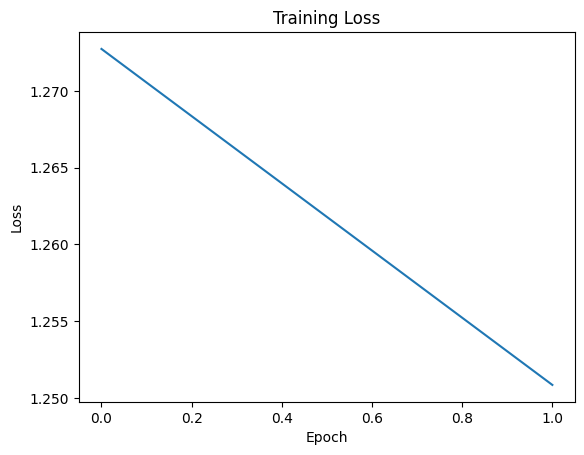

In [17]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

Prints some results after training (beyond loss)

In [18]:
def predict_probs(X, weights):
    return np.array([float(quantum_model(x, weights)) for x in X])

train_probs = predict_probs(Xq_train_small[:50], weights)
test_probs = predict_probs(Xq_test_angles[:50], weights)

print("First 10 test probs:", test_probs[:10])

test_preds = (test_probs >= 0.5).astype(int)
print("First 10 test predictions:", test_preds[:10])
print("First 10 true labels:", yq_test[:10])

First 10 test probs: [0.6249365 0.4426589 0.4426589 0.4426589 0.4426589 0.2785867 0.2785867
 0.2785867 0.2785867 0.2785867]
First 10 test predictions: [1 0 0 0 0 0 0 0 0 0]
First 10 true labels: [0 0 0 0 0 0 0 0 0 0]


Zip-level risk scores

In [19]:
test_probs_full = predict_probs(Xq_test_angles, weights)

results_df = test_df[id_cols + q_features + [target]].copy()
results_df['qml_risk_score'] = test_probs_full
results_df[['zip', 'Year', 'qml_risk_score']].head()

zip_scores = (results_df.groupby('zip', as_index=False)['qml_risk_score'].max().sort_values('qml_risk_score', ascending=False))

zip_scores.head(10)

,zip,qml_risk_score
44,93308.0,0.825214
30,93226.0,0.825214
54,93453.0,0.825214
42,93287.0,0.825214
23,93066.0,0.825214
57,93465.0,0.825214
45,93401.0,0.779628
34,93249.0,0.779628
35,93251.0,0.779628
49,93428.0,0.779628
